<a href="https://colab.research.google.com/github/kavyaayyappan1998/DATA266---2738/blob/main/neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# My SJSU ID is : 016052738
SID4 = 2738
SEED = 2738
SLICE = 738
HP_ID = 2
CLS_A = 8
CLS_B = 2

In [ ]:
# For stochastic code, set the Python random, NumPy and framework seed explicitly.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(SEED)


## 2. Diabetes Dataset: Neural Network Implementation


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [ ]:
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv("diabetes.csv", header=None, names=columns)

# Make sure the target is binary.
assert set(df["Outcome"].unique()).issubset({0, 1})

print("Shape:", df.shape)
display(df.head())
print("\nTarget counts:")
print(df["Outcome"].value_counts())

Shape: (759, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0



Target counts:
Outcome
1    496
0    263
Name: count, dtype: int64


 Visualize the Data: Correlation Matrix, Feature Distributions

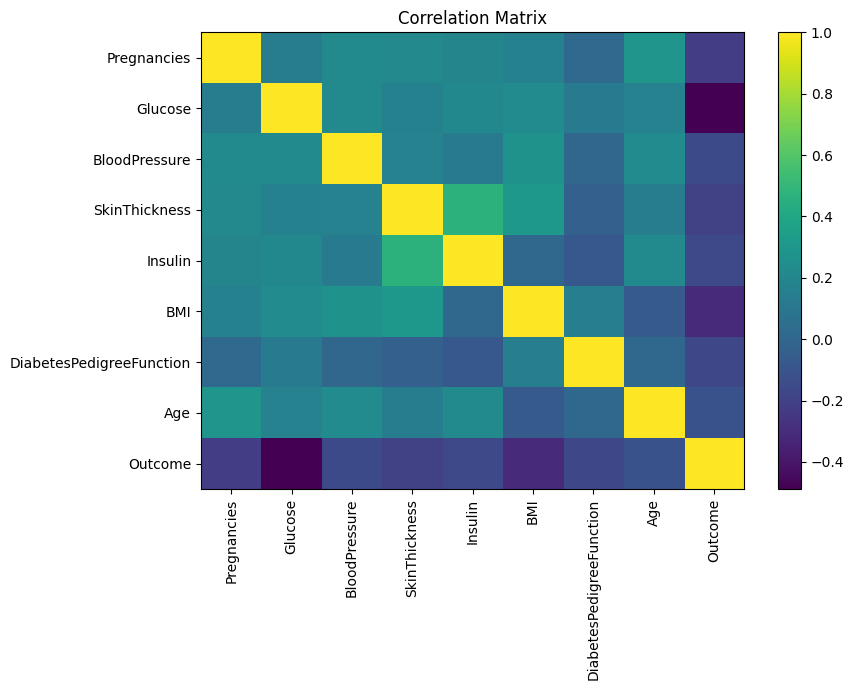

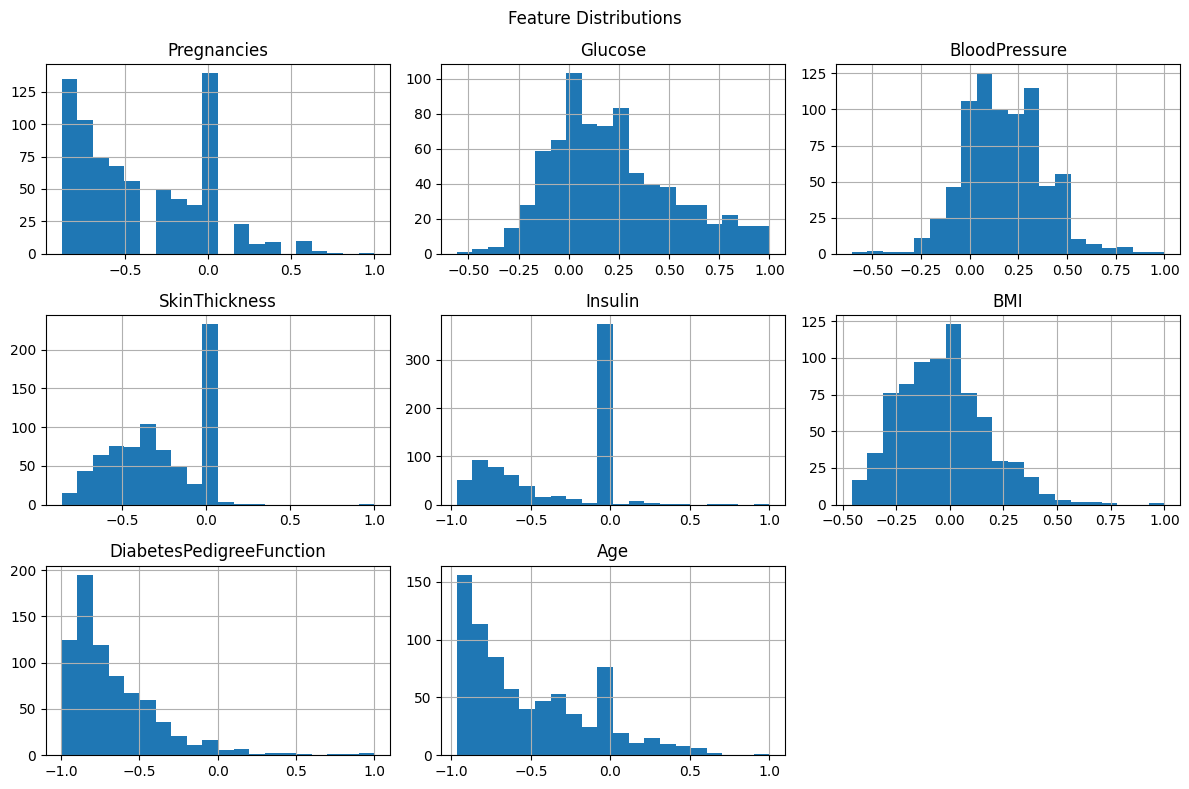

In [ ]:
# Correlation matrix
corr = df.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Feature distributions
features = df.columns[:-1]
df[features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


Split the dataset into training (70%), validation (15%), and testing (15%) subsets using random_state = SEED. Use the same split for every model comparison.

In [ ]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

# First split: 70% train and 30% remaining.
X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Split the remaining 30% equally into validation and test.
X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Fit the scaler only on training data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype("float32")
X_val = scaler.transform(X_val_df).astype("float32")
X_test = scaler.transform(X_test_df).astype("float32")

y_train_np = y_train.to_numpy(dtype="float32").reshape(-1, 1)
y_val_np = y_val.to_numpy(dtype="float32").reshape(-1, 1)
y_test_np = y_test.to_numpy(dtype="float32").reshape(-1, 1)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (531, 8)
Validation: (114, 8)
Test: (114, 8)


Implement the same baseline feedforward neural network in PyTorch : hidden layers [64, 32], learning rate 0.001, and 30 epochs. Use the same preprocessing and evaluation metric in both frameworks.

Implement one modified model in each framework using your HP_ID configuration below. The HP_ID configuration counts as the required modified model; you do not need a third model.
HP_ID 2: hidden layers [64, 32]; learning rate 0.003; 30 epochs.

In [ ]:
X_train_t = torch.tensor(X_train)
X_val_t = torch.tensor(X_val)
X_test_t = torch.tensor(X_test)

y_train_t = torch.tensor(y_train_np)
y_val_t = torch.tensor(y_val_np)
y_test_t = torch.tensor(y_test_np)

class DiabetesNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_pytorch(lr, seed, epochs=30):
    set_seed(seed)

    model = DiabetesNet(X_train.shape[1])
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss, val_loss = [], []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()

        loss = loss_fn(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss.append(
                loss_fn(model(X_val_t), y_val_t).item()
            )

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test_t))
        predictions = (probs >= 0.5).float()
        accuracy = (predictions == y_test_t).float().mean().item()

    return accuracy, train_loss, val_loss


Compare the baseline and HP_ID-modified models in each framework using the same split and metric.

In [ ]:
TRAINING_SEEDS = [SEED, SEED + 1, SEED + 2]
configs = {
    "Baseline": 0.001,
    "Modified_HP2": 0.003
}

pytorch_results = []
pytorch_history = {}

for model_name, lr in configs.items():
    for seed in TRAINING_SEEDS:
        accuracy, train_loss, val_loss = train_pytorch(lr, seed)

        pytorch_results.append({
            "Framework": "PyTorch",
            "Model": model_name,
            "LearningRate": lr,
            "Seed": seed,
            "TestAccuracy": accuracy
        })

        if seed == SEED:
            pytorch_history[model_name] = {
                "train": train_loss,
                "val": val_loss
            }

        print(f"PyTorch | {model_name} | seed={seed} | accuracy={accuracy:.4f}")


PyTorch | Baseline | seed=2738 | accuracy=0.7105
PyTorch | Baseline | seed=2739 | accuracy=0.6754
PyTorch | Baseline | seed=2740 | accuracy=0.6491
PyTorch | Modified_HP2 | seed=2738 | accuracy=0.6930
PyTorch | Modified_HP2 | seed=2739 | accuracy=0.6842
PyTorch | Modified_HP2 | seed=2740 | accuracy=0.7193


Implement the same baseline feedforward neural network in TensorFlow

In [ ]:
# Implement the same baseline feedforward neural network in PyTorch and TensorFlow: hidden layers [64, 32], learning rate 0.001, and 30 epochs. Use the same preprocessing and evaluation metric in both frameworks.
# Implement one modified model in each framework using your HP_ID configuration below. The HP_ID configuration counts as the required modified model; you do not need a third model.
# HP_ID 2: hidden layers [64, 32]; learning rate 0.003; 30 epochs.

def train_tensorflow(lr, seed, epochs=30):
    tf.keras.backend.clear_session()
    set_seed(seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train_np,
        validation_data=(X_val, y_val_np),
        epochs=epochs,
        batch_size=len(X_train),
        verbose=0
    )

    _, accuracy = model.evaluate(X_test, y_test_np, verbose=0)

    return (
        float(accuracy),
        history.history["loss"],
        history.history["val_loss"]
    )

tensorflow_results = []
tensorflow_history = {}

for model_name, lr in configs.items():
    for seed in TRAINING_SEEDS:
        accuracy, train_loss, val_loss = train_tensorflow(lr, seed)

        tensorflow_results.append({
            "Framework": "TensorFlow",
            "Model": model_name,
            "LearningRate": lr,
            "Seed": seed,
            "TestAccuracy": accuracy
        })

        if seed == SEED:
            tensorflow_history[model_name] = {
                "train": train_loss,
                "val": val_loss
            }

        print(f"TensorFlow | {model_name} | seed={seed} | accuracy={accuracy:.4f}")


TensorFlow | Baseline | seed=2738 | accuracy=0.7105
TensorFlow | Baseline | seed=2739 | accuracy=0.7105
TensorFlow | Baseline | seed=2740 | accuracy=0.7281
TensorFlow | Modified_HP2 | seed=2738 | accuracy=0.7456
TensorFlow | Modified_HP2 | seed=2739 | accuracy=0.7018
TensorFlow | Modified_HP2 | seed=2740 | accuracy=0.7281


## Measurement and analysis


#### 1. Keep the data split fixed with random_state = SEED. Train the baseline and modified networks three times using training seeds SEED, SEED+1, and SEED+2. Report mean and standard deviation of test accuracy for each model and framework.

In [ ]:
results_df = pd.DataFrame(pytorch_results + tensorflow_results)

summary_df = (
    results_df
    .groupby(["Framework", "Model", "LearningRate"])["TestAccuracy"]
    .agg(
        MeanTestAccuracy="mean",
        StdTestAccuracy=lambda x: np.std(x, ddof=0)
    )
    .reset_index()
)

display(results_df)
print("\nMean and standard deviation:")
display(summary_df)


,Framework,Model,LearningRate,Seed,TestAccuracy
0,PyTorch,Baseline,0.001,2738,0.710526
1,PyTorch,Baseline,0.001,2739,0.675439
2,PyTorch,Baseline,0.001,2740,0.649123
3,PyTorch,Modified_HP2,0.003,2738,0.692982
4,PyTorch,Modified_HP2,0.003,2739,0.684211
5,PyTorch,Modified_HP2,0.003,2740,0.719298
6,TensorFlow,Baseline,0.001,2738,0.710526
7,TensorFlow,Baseline,0.001,2739,0.710526
8,TensorFlow,Baseline,0.001,2740,0.728070
9,TensorFlow,Modified_HP2,0.003,2738,0.745614



Mean and standard deviation:


,Framework,Model,LearningRate,MeanTestAccuracy,StdTestAccuracy
0,PyTorch,Baseline,0.001,0.678363,0.025153
1,PyTorch,Modified_HP2,0.003,0.698830,0.014909
2,TensorFlow,Baseline,0.001,0.716374,0.008270
3,TensorFlow,Modified_HP2,0.003,0.725146,0.018025


#### 2. For the SEED run, plot training and validation loss per epoch for baseline and modified models on one figure per framework. State whether the modified model is better, overfitting, underfitting, or indistinguishable, and cite the relevant part of the curves.

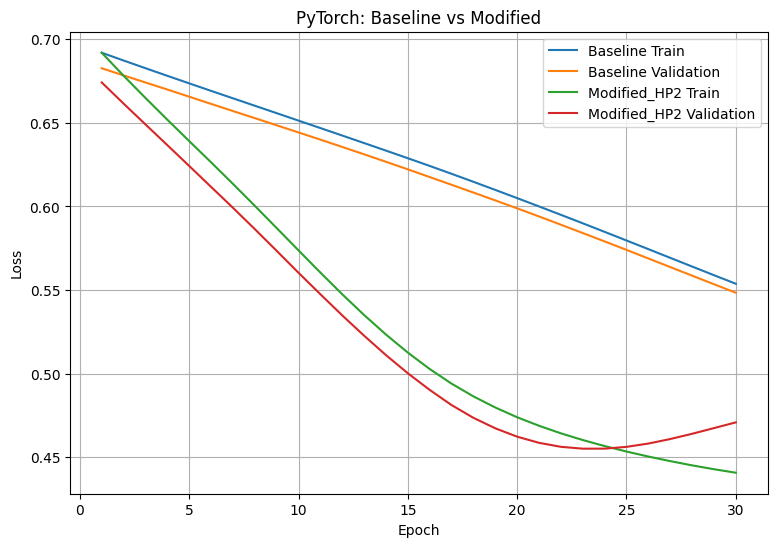

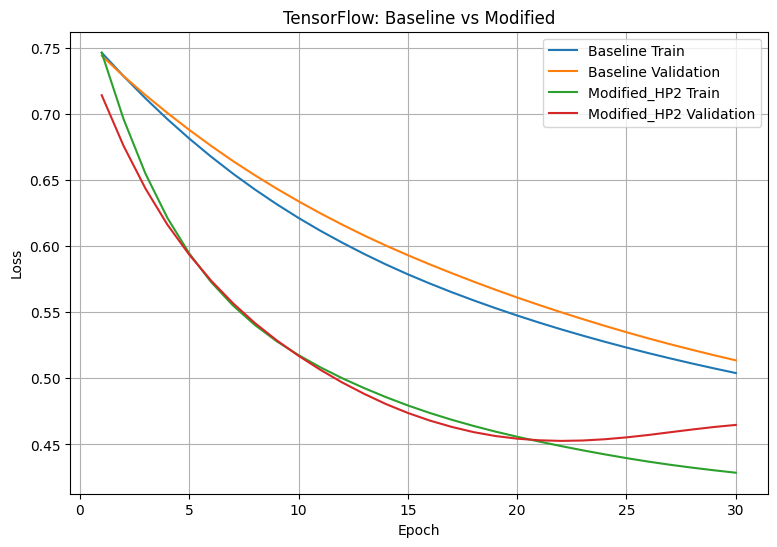

In [ ]:
def plot_losses(history, framework):
    epochs = range(1, 31)

    plt.figure(figsize=(9, 6))

    for model_name in ["Baseline", "Modified_HP2"]:
        plt.plot(
            epochs,
            history[model_name]["train"],
            label=f"{model_name} Train"
        )
        plt.plot(
            epochs,
            history[model_name]["val"],
            label=f"{model_name} Validation"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{framework}: Baseline vs Modified")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(pytorch_history, "PyTorch")
plot_losses(tensorflow_history, "TensorFlow")


### Interpretation

#### PyTorch
- The modified model performs better than the baseline because the validation loss is lower.
- After around epoch 22, the training loss keeps going down, but the validation loss starts going up slightly.
This shows a small amount of overfitting.
#### TensorFlow
- The modified model also performs better than the baseline because it has a lower validation loss.
- After around epoch 20–22, the training loss keeps decreasing while the validation loss starts increasing a little.
- This also shows mild overfitting.


#### 3. Report your HP_ID and the exact modified configuration you used. Even if it performs worse than the baseline, it is still the required modified model.

In [ ]:
print("HP_ID =", HP_ID)
print("Modified hidden layers = [64, 32]")
print("Modified learning rate = 0.003")
print("Modified epochs = 30")


HP_ID = 2
Modified hidden layers = [64, 32]
Modified learning rate = 0.003
Modified epochs = 30


In [ ]:
for framework in ["PyTorch", "TensorFlow"]:
    rows = summary_df[summary_df["Framework"] == framework]

    baseline = rows[rows["Model"] == "Baseline"].iloc[0]
    modified = rows[rows["Model"] == "Modified_HP2"].iloc[0]

    difference = (
        modified["MeanTestAccuracy"]
        - baseline["MeanTestAccuracy"]
    )

    print(f"\n{framework}")
    print(f"Baseline mean accuracy: {baseline['MeanTestAccuracy']:.4f}")
    print(f"Modified mean accuracy: {modified['MeanTestAccuracy']:.4f}")
    print(f"Difference: {difference:+.4f}")



PyTorch
Baseline mean accuracy: 0.6784
Modified mean accuracy: 0.6988
Difference: +0.0205

TensorFlow
Baseline mean accuracy: 0.7164
Modified mean accuracy: 0.7251
Difference: +0.0088


### Conclusion

- The modified model performed a little better than the baseline in both PyTorch and TensorFlow.
- PyTorch improved from 0.6784 to 0.6988, and TensorFlow improved from 0.7164 to 0.7251.
- Overall, the modified TensorFlow model gave the best accuracy.
